#Splitting the data into Train and Test Datasets

## **1. Import Python Libraries**

In [ ]:
import marimo as mo
import marimo as mo
import pyspark 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import os
from pyspark.sql import SparkSession
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml import Pipeline

## **2. Initialize Apache Spark Session**

In [ ]:
spark = SparkSession.builder.appName("Loan_Application_Classifier").getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/13 20:01:26 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/13 20:01:26 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/04/13 20:01:26 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


## **3. Setup File Paths**

In [ ]:
# Setup the base path
base_dir = os.path.abspath('/Users/ananddivakaran/Documents/Anand/MDS/loan_app')
print(f'Base Data Directory:{base_dir}')
input_path = f"file://{os.path.join(base_dir,'data/interim/loan_data_interim.csv')}"
print(f'Input file: {input_path}')
output_path_train = os.path.join(base_dir, "data/processed/loan_data_train")
print(f'Train file:{output_path_train}')
output_path_test = os.path.join(base_dir, "data/processed/loan_data_test")
print(f'Test file:{output_path_test}')

Base Data Directory:/Users/ananddivakaran/Documents/Anand/MDS/loan_app
Input file: file:///Users/ananddivakaran/Documents/Anand/MDS/loan_app/data/interim/loan_data_interim.csv
Train file:/Users/ananddivakaran/Documents/Anand/MDS/loan_app/data/processed/loan_data_train
Test file:/Users/ananddivakaran/Documents/Anand/MDS/loan_app/data/processed/loan_data_test


## **4. Load the dataset**

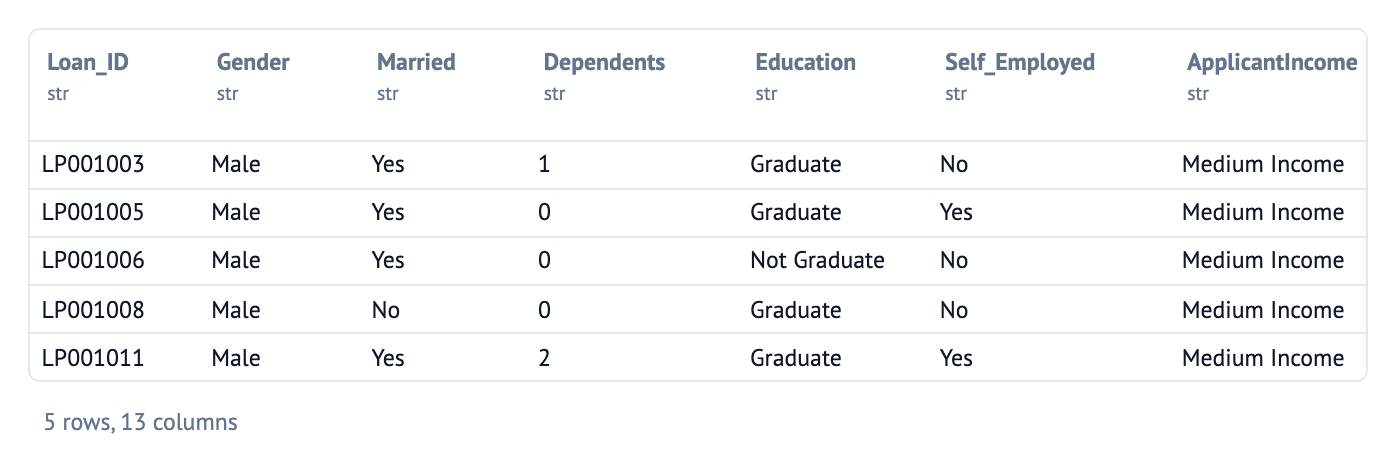

In [ ]:
# Read data
data_processed = spark.read.csv(input_path, header=True, inferSchema=True)
# Converting the data to pandas dataframe for easy analysis
df = data_processed.toPandas()
df.head(5)

## **5. Split the data**

### Splitting the data into Train and Test Data with 70:30 ratio.

In [ ]:
train_data, test_data = data_processed.randomSplit([0.7, 0.3], seed=42)
train_data_df = train_data.toPandas()
test_data_df = test_data.toPandas()

In [ ]:
print(f'Count of Train Dataset: {train_data.count()}')

Count of Train Dataset: 441


In [ ]:
print(f'Count of Train Dataset: {test_data.count()}')

Count of Train Dataset: 151


In [ ]:
train_data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 441 entries, 0 to 440
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            441 non-null    str    
 1   Gender             433 non-null    str    
 2   Married            441 non-null    str    
 3   Dependents         441 non-null    str    
 4   Education          441 non-null    str    
 5   Self_Employed      441 non-null    str    
 6   ApplicantIncome    441 non-null    str    
 7   CoapplicantIncome  441 non-null    str    
 8   LoanAmount         441 non-null    float64
 9   Loan_Amount_Term   432 non-null    str    
 10  Credit_History     441 non-null    str    
 11  Property_Area      441 non-null    str    
 12  Loan_Status        441 non-null    int32  
dtypes: float64(1), int32(1), str(11)
memory usage: 74.7 KB


In [ ]:
train_data_df['Credit_History'] = train_data_df['Credit_History'].astype('category')
test_data_df['Credit_History'] = test_data_df['Credit_History'].astype('category')

In [ ]:
train_data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 441 entries, 0 to 440
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Loan_ID            441 non-null    str     
 1   Gender             433 non-null    str     
 2   Married            441 non-null    str     
 3   Dependents         441 non-null    str     
 4   Education          441 non-null    str     
 5   Self_Employed      441 non-null    str     
 6   ApplicantIncome    441 non-null    str     
 7   CoapplicantIncome  441 non-null    str     
 8   LoanAmount         441 non-null    float64 
 9   Loan_Amount_Term   432 non-null    str     
 10  Credit_History     441 non-null    category
 11  Property_Area      441 non-null    str     
 12  Loan_Status        441 non-null    int32   
dtypes: category(1), float64(1), int32(1), str(10)
memory usage: 70.5 KB


## **6. Handle NULLS after the split (Imputation)**

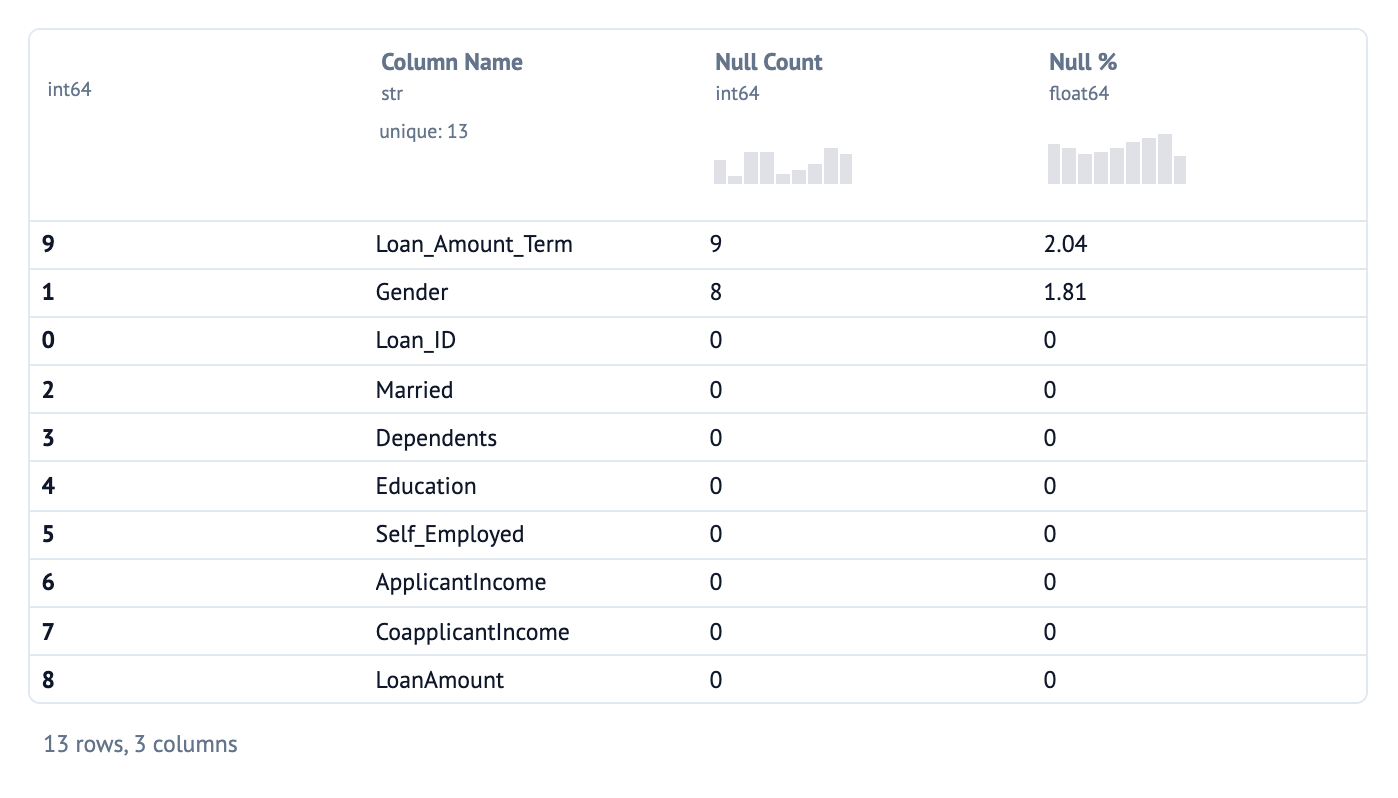

In [ ]:
def check_missing_data(df):
    report = []

    for col in df.columns:
        # 1. Count actual Nulls (NaN)
        null_count = df[col].isnull().sum()
        total_rows = len(df)
        null_percent = (null_count / total_rows) * 100

        report.append({
            'Column Name': col,
            'Null Count': null_count,
            'Null %': round(null_percent, 2)
        })

    return pd.DataFrame(report).sort_values('Null Count', ascending=False)

# Run the check
missing_report = check_missing_data(train_data_df)
pd.DataFrame(missing_report)

Nulls are present in the below features <br>
1. Loan Amount Term - Fill it with the mode value
2. Gender - Use the mode to fill the null

### 6.1 Handle NULLs in the feture - Loan Amount Term

In [ ]:
# Find the mode from the train dataset
median_loan_term = train_data_df.Loan_Amount_Term.mode()
# Fill the nulls with mode in train dataset
train_data_df['Loan_Amount_Term'] = train_data_df['Loan_Amount_Term'].fillna(median_loan_term[0])
# Fill the nulls with mode in test dataset - avoid data leakage
test_data_df['Loan_Amount_Term'] = test_data_df['Loan_Amount_Term'].fillna(median_loan_term[0])

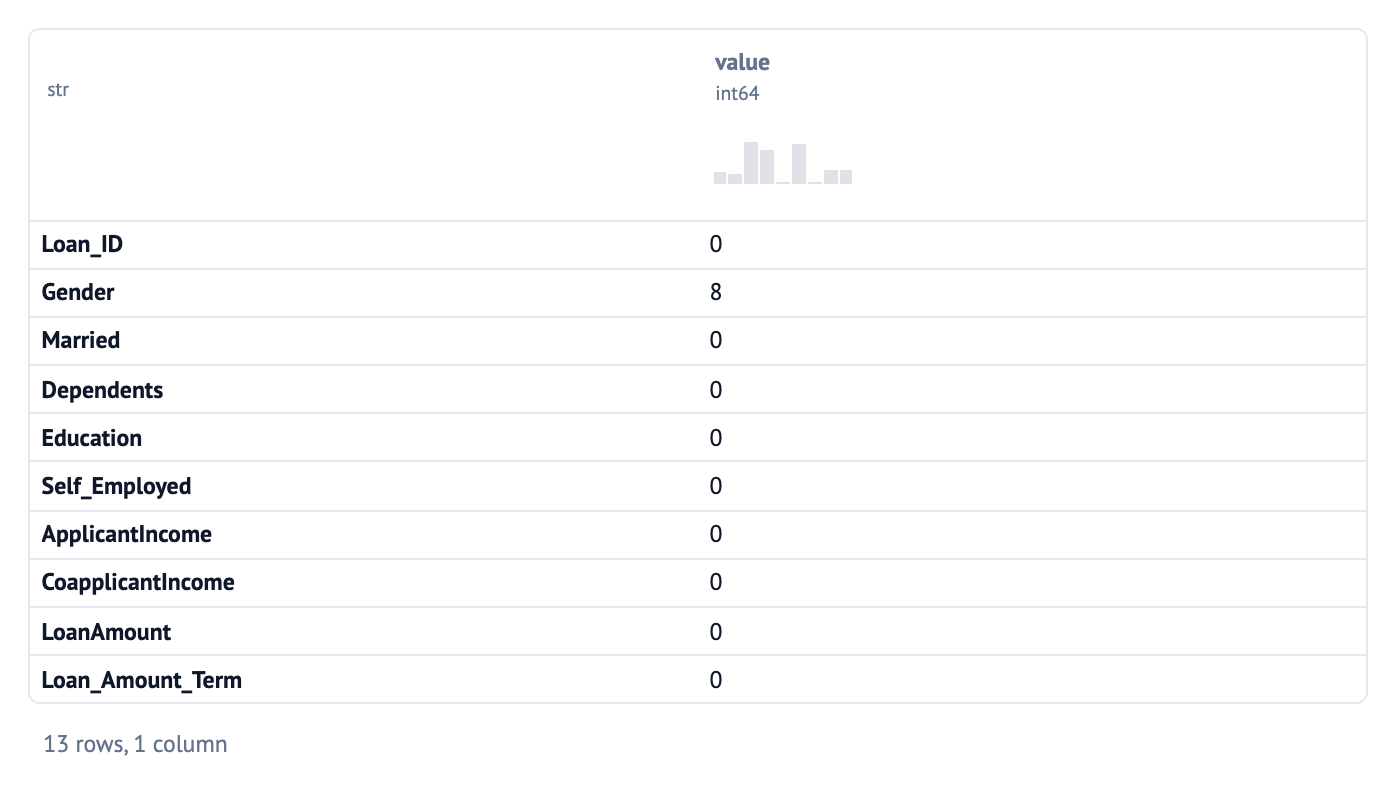

In [ ]:
train_data_df.isnull().sum()

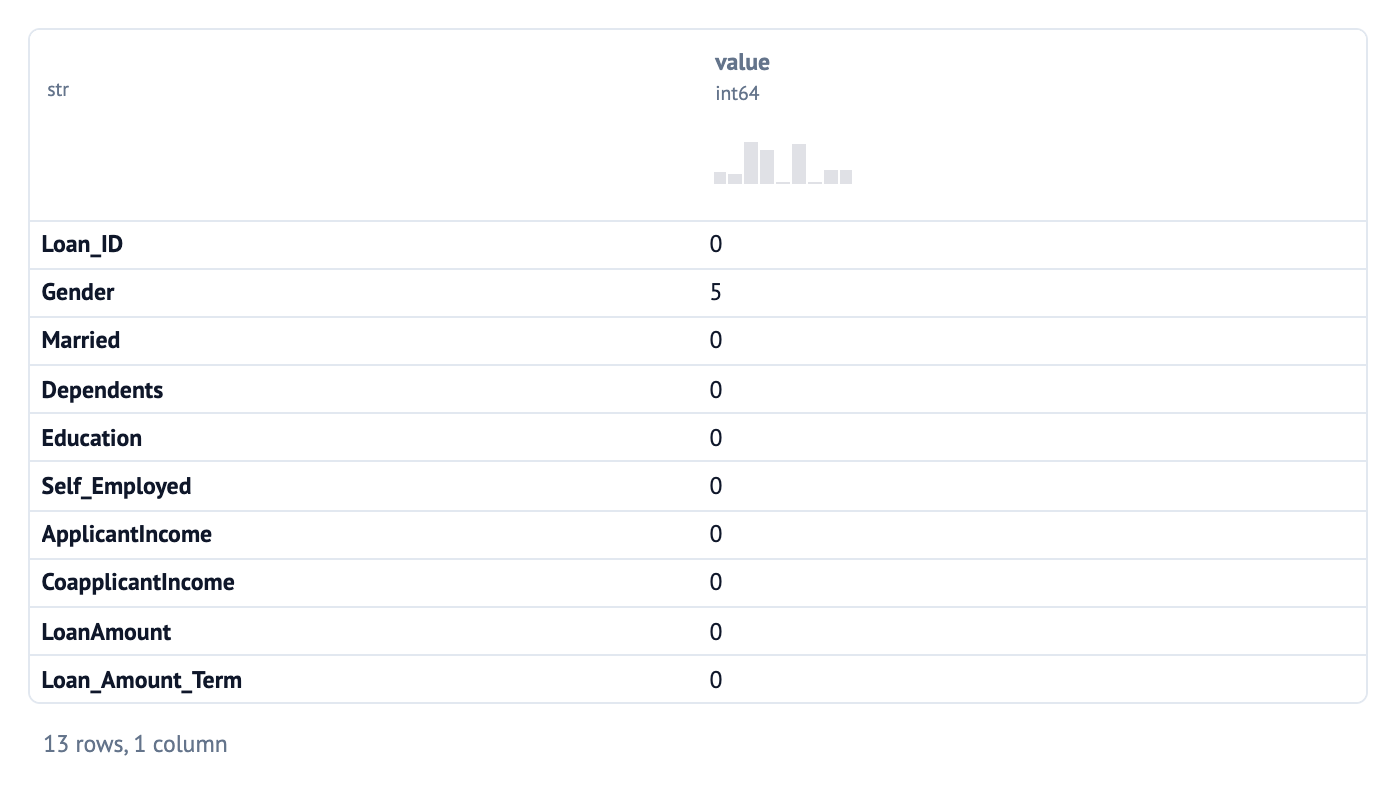

In [ ]:
test_data_df.isnull().sum()

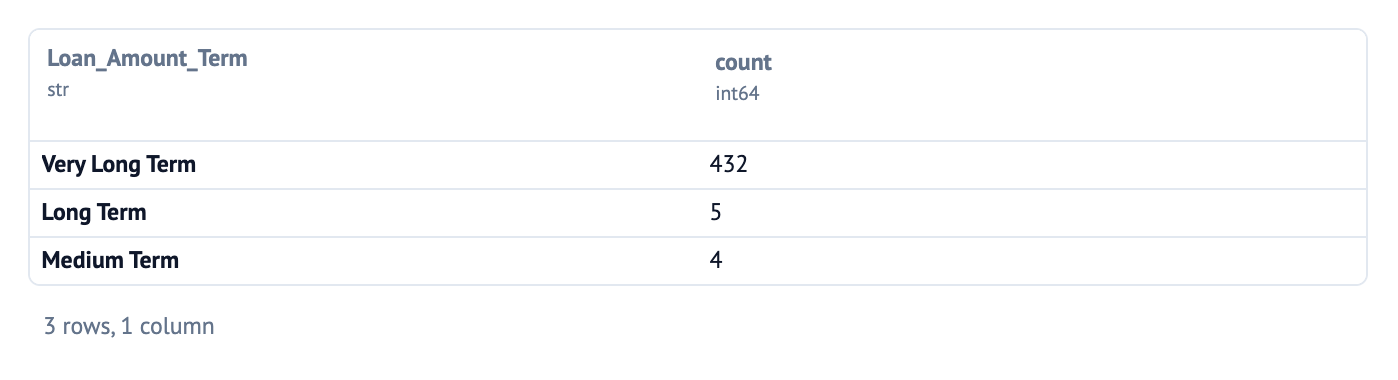

In [ ]:
train_data_df.Loan_Amount_Term.value_counts()

### 6.2 Handle NULLs in the feture - Gender

In [ ]:
# Find the mode from the train dataset
median_gender = train_data_df.Gender.mode()
# Fill the nulls with mode in train dataset
train_data_df['Gender'] = train_data_df['Gender'].fillna(median_gender[0])
# Fill the nulls with mode in test dataset - avoid data leakage
test_data_df['Gender'] = test_data_df['Gender'].fillna(median_gender[0])

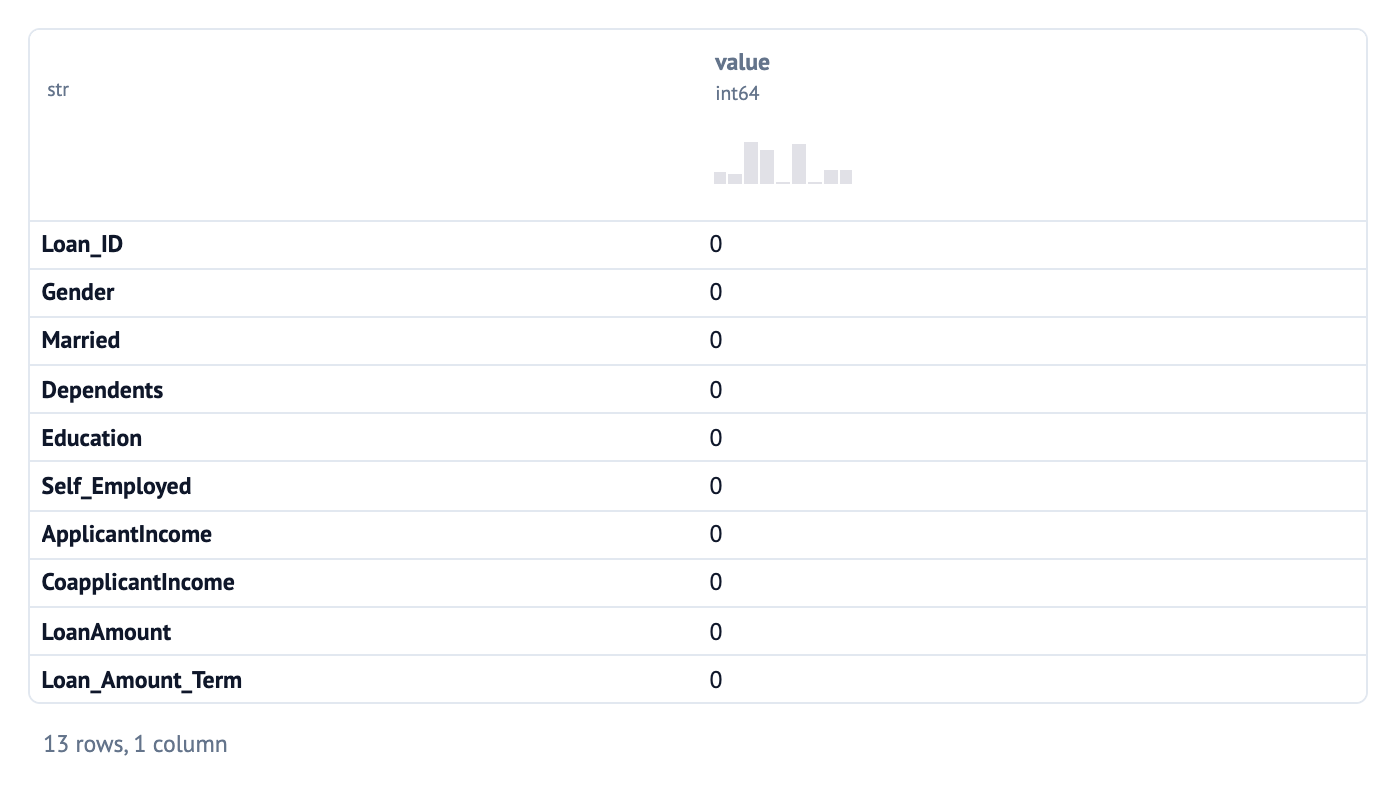

In [ ]:
train_data_df.isnull().sum()

## **7. Saving the data in the folder**

In [ ]:
train_data.write.option("header", "true") \
        .option("sep", ",") \
        .mode("overwrite") \
        .csv(output_path_train)

test_data.write.option("header", "true") \
        .option("sep", ",") \
        .mode("overwrite") \
        .csv(output_path_test)

## **8. Stop the spark session**

In [ ]:
spark.stop()